# 01_train_results

- Loads and compares results from all loss function ablation runs in 01_train_study
- Plots train loss curves and val SI-SDR curves per stage
- IDs winner of each paired comparison
- Documents final loss function selection carried forward to 01_train_final

In [1]:
import sys
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, "..")
from config import *

%matplotlib widget

l1: best val SI-SDR = 18.6729 dB (58 epochs)
weighted_l1: best val SI-SDR = 21.2540 dB (55 epochs)

Stage 1a winner: weighted_l1


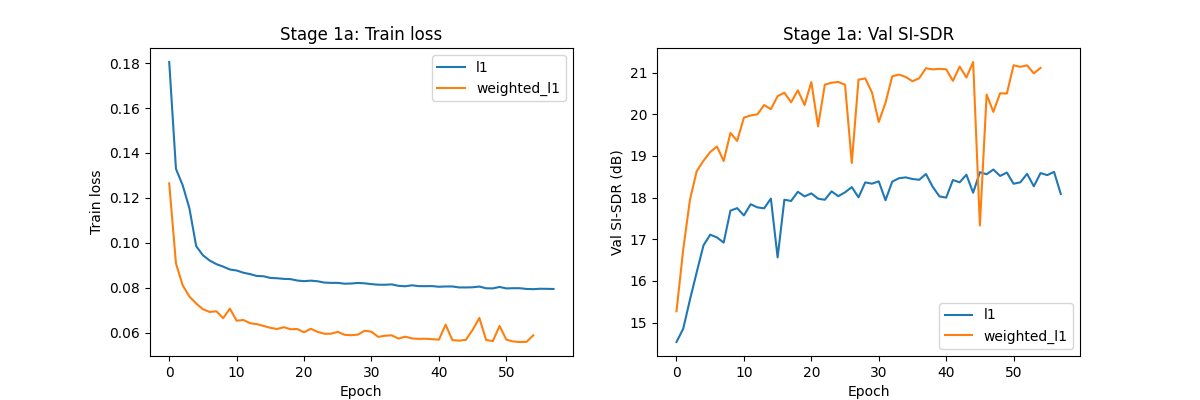

In [2]:
# Stage 1a — waveform loss comparison: l1 vs weighted_l1

runs_1a = ["l1", "weighted_l1"]
results_1a = {}

for run_name in runs_1a:
    results_path = STUDY_OUT / run_name / "results.json"
    with open(results_path) as f:
        results_1a[run_name] = json.load(f)
    print(f"{run_name}: best val SI-SDR = {results_1a[run_name]['best_val_sdr']:.4f} dB "
          f"({results_1a[run_name]['epochs']} epochs)")

winner_1a = max(runs_1a, key=lambda r: results_1a[r]["best_val_sdr"])
print(f"\nStage 1a winner: {winner_1a}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for run_name in runs_1a:
    axes[0].plot(results_1a[run_name]["train_loss_history"], label=run_name)
    axes[1].plot(results_1a[run_name]["val_sdr_history"], label=run_name)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Train loss")
axes[0].set_title("Stage 1a: Train loss")
axes[0].legend()

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val SI-SDR (dB)")
axes[1].set_title("Stage 1a: Val SI-SDR")
axes[1].legend()

plt.show()

### Stage 1b Results — Weight power tuning

| Run | Best val SI-SDR | Epochs |
|-----|----------------|--------|
| weighted_l1 (p=1) | 21.2540 dB | 55 |
| weighted_l1_p2 (p=2) | 21.2034 dB | 67 |
| weighted_l1_p4 (p=4) | 20.5662 dB | 67* |

*p4 run was interrupted at 67 epochs due to training time — convergence not confirmed.
p2 and p4 runs were slower to converge than p=1

Result: p=1 wins marginally over p=2 (0.05 dB difference), and both outperform p=4.
Given the negligible difference between p=1 and p=2 and the faster convergence of p=1,
weighted_l1 (p=1) carries forward as the waveform loss component for stage 1c.

### Stage 1c Results — Spectral loss comparison

| Run | Best val SI-SDR | Epochs |
|-----|----------------|--------|
| weighted_l1 (no spectral) | 21.2540 dB | 55 |
| weighted_l1_stft | 21.8954 dB | 91 |
| weighted_l1_dwt | 21.9302 dB | 83 |

Both spectral loss terms improve over waveform loss alone, confirming the literature.
DWT marginally outperforms STFT (0.035 dB difference) while converging faster (83 vs 91 epochs).
Given the negligible margin, either could be justified - DWT carries forward to stage 2
on the basis of faster convergence and slightly higher peak SI-SDR.

Stage 1c winner: weighted_l1_dwt

### Stage 1d Results — DWT level test

| Run | Best val SI-SDR | Epochs |
|-----|----------------|--------|
| weighted_l1_dwt | 20.359 dB | 50 |

1d run was cut off at 50 epochs in consideration of time. There is a chance that a different number of DWT levels would provide benefit, but it was assumed it would be slim, and so 4 levels was concluded to be sufficient to move along testing. This area could be explored more deeply if training were faster (GPUs etc).

Stage 1d result: Use default DWT w 4 levels

### Stage 1d Results — DWT level test

| Run | Best val SI-SDR | Epochs |
|-----|----------------|--------|
| weighted_l1_dwt_weighted | 20.6464 dB | ? |

After a significant number of epochs (no convergence reached though), weighted dwt did not seem to improve SI-SDR. As with other ablation tests, with faster training, a more complex weighted spectral loss is likely worth exploring further.

Stage 2 Result: Use weighted_l1_dwt (unweighted DWT)

## Final training

In [3]:
# Compute baseline SI-SDR on validation data

from util import DeclipDataset, si_sdr
from torch.utils.data import DataLoader

val_dataset = DeclipDataset(VAL_OUT / "val_blocks.pt", VAL_OUT / "val_manifest.json")
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Clipped input SI-SDR
total_sdr = 0.0
total_count = 0
with torch.no_grad():
    for clipped, clean in val_loader:
        clipped, clean = clipped.to(DEVICE), clean.to(DEVICE)
        scores = si_sdr(clean, clipped)
        total_sdr += scores.sum().item()
        total_count += scores.numel()

clipped_baseline_sdr = total_sdr / total_count
print(f"Clipped input val SI-SDR baseline: {clipped_baseline_sdr:.4f} dB")

Clipped input val SI-SDR baseline: 15.7460 dB


Run: weighted_l1_dwt
Epochs: 162
Complete: True
Best val SI-SDR:      22.4329 dB
Clipped baseline SDR: 15.7460 dB
Improvement:          6.6869 dB


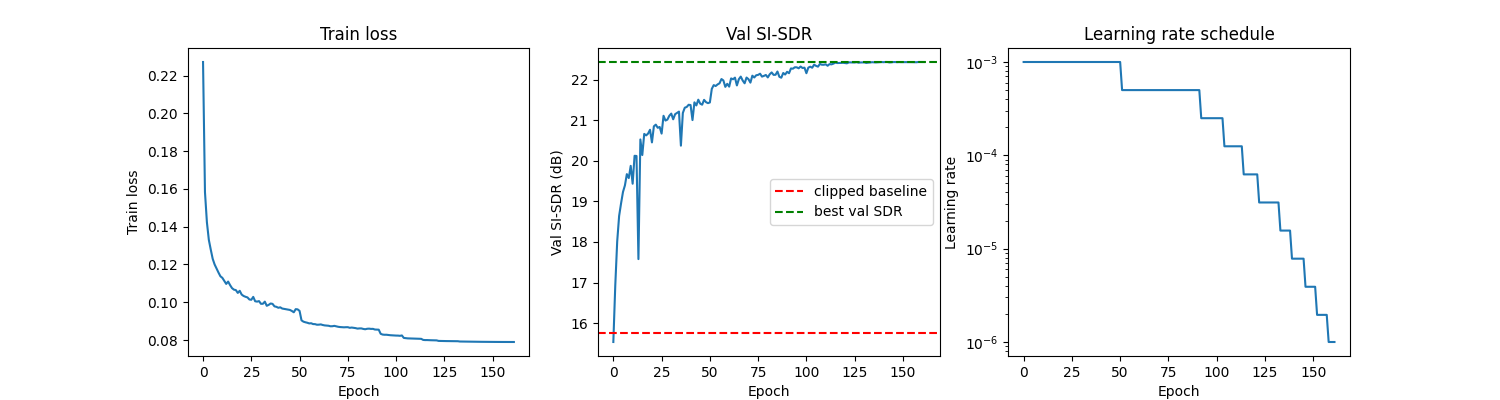

In [4]:
# Load final training results
results_path = FINAL_OUT / "weighted_l1_dwt" / "results.json"
with open(results_path) as f:
    final_results = json.load(f)

print(f"Run: {final_results['run_name']}")
print(f"Epochs: {final_results['epochs']}")
print(f"Complete: {final_results['complete']}")
print(f"Best val SI-SDR:      {final_results['best_val_sdr']:.4f} dB")
print(f"Clipped baseline SDR: {clipped_baseline_sdr:.4f} dB")
print(f"Improvement:          {final_results['best_val_sdr'] - clipped_baseline_sdr:.4f} dB")

# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(final_results["train_loss_history"])
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Train loss")
axes[0].set_title("Train loss")

axes[1].plot(final_results["val_sdr_history"])
axes[1].axhline(y=clipped_baseline_sdr, color='r', linestyle='--', label='clipped baseline')
axes[1].axhline(y=final_results["best_val_sdr"], color='g', linestyle='--', label='best val SDR')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val SI-SDR (dB)")
axes[1].set_title("Val SI-SDR")
axes[1].legend()

axes[2].plot(final_results["lr_history"])
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning rate")
axes[2].set_title("Learning rate schedule")
axes[2].set_yscale('log')

plt.show()

In [5]:
# Test set eval

import torchaudio
from pesq import pesq as pesq_fn
from util import DeclipNet

# Model
H = 8
N_ATTN = 3
NUM_HEADS = 4
FFN_DIM = 256

model = DeclipNet(H=H, N=N_ATTN, num_heads=NUM_HEADS, ffn_dim=FFN_DIM).to(DEVICE)
state_dict = torch.load(FINAL_OUT / "weighted_l1_dwt" / "best_model.pt", weights_only=True)
state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)
model.eval()

with open(TEST_OUT / "test_manifest.json") as f:
    test_manifest = json.load(f)

test_sdr_scores = []
test_baseline_scores = []
test_pesq_scores = []
test_baseline_pesq_scores = []

for entry in test_manifest:
    # Load clean utterance
    clean = torch.load(TEST_OUT / f"test_{entry['file_idx']:03d}_clean.pt", weights_only=True).to(DEVICE)

    # Apply clipping from manifest alpha
    peak = clean.abs().max()
    threshold = entry["alpha"] * peak
    clipped = clean.clamp(-threshold, threshold)

    # Chunk into non-overlapping blocks
    n_blocks = clean.shape[1] // BS
    if n_blocks == 0:
        continue
    clean_chunks = clean[:, :n_blocks * BS].unfold(1, BS, BS).squeeze(0).unsqueeze(1)
    clipped_chunks = clipped[:, :n_blocks * BS].unfold(1, BS, BS).squeeze(0).unsqueeze(1)

    # Run inference
    with torch.no_grad():
        output_chunks = model(clipped_chunks)

    # Reconstruct output utterance
    output = output_chunks.squeeze(1).reshape(1, -1)
    clean_trimmed = clean[:, :n_blocks * BS]
    clipped_trimmed = clipped[:, :n_blocks * BS]

    # SI-SDR
    utt_sdr = si_sdr(clean_trimmed, output).mean().item()
    baseline_sdr = si_sdr(clean_trimmed, clipped_trimmed).mean().item()
    test_sdr_scores.append(utt_sdr)
    test_baseline_scores.append(baseline_sdr)

    # PESQ — requires 1D numpy arrays on CPU
    clean_np = clean_trimmed.squeeze().cpu().numpy()
    output_np = output.squeeze().cpu().numpy()
    clipped_np = clipped_trimmed.squeeze().cpu().numpy()

    try:
        utt_pesq = pesq_fn(FS, clean_np, output_np, 'wb')
        baseline_pesq = pesq_fn(FS, clean_np, clipped_np, 'wb')
    except Exception as e:
        print(f"PESQ failed for utterance {entry['file_idx']:03d}: {e}")
        utt_pesq = float('nan')
        baseline_pesq = float('nan')

    test_pesq_scores.append(utt_pesq)
    test_baseline_pesq_scores.append(baseline_pesq)

    print(f"utt {entry['file_idx']:03d} | "
          f"SDR: {baseline_sdr:.2f} -> {utt_sdr:.2f} dB (delta: {utt_sdr - baseline_sdr:.2f}) | "
          f"PESQ: {baseline_pesq:.3f} -> {utt_pesq:.3f}",
          flush=True)

mean_test_sdr = np.mean(test_sdr_scores)
mean_baseline_sdr = np.mean(test_baseline_scores)
mean_test_pesq = np.nanmean(test_pesq_scores)
mean_baseline_pesq = np.nanmean(test_baseline_pesq_scores)

print(f"\nMean test SI-SDR:     {mean_test_sdr:.4f} dB")
print(f"Mean baseline SI-SDR: {mean_baseline_sdr:.4f} dB")
print(f"SI-SDR improvement:   {mean_test_sdr - mean_baseline_sdr:.4f} dB")
print(f"\nMean test PESQ:       {mean_test_pesq:.4f}")
print(f"Mean baseline PESQ:   {mean_baseline_pesq:.4f}")
print(f"PESQ improvement:     {mean_test_pesq - mean_baseline_pesq:.4f}")

utt 000 | SDR: 17.52 -> 27.32 dB (delta: 9.80) | PESQ: 2.601 -> 3.422
utt 001 | SDR: 3.85 -> 12.05 dB (delta: 8.20) | PESQ: 1.199 -> 1.873
utt 002 | SDR: 10.45 -> 19.38 dB (delta: 8.94) | PESQ: 1.523 -> 2.583
utt 003 | SDR: 25.96 -> 33.72 dB (delta: 7.76) | PESQ: 3.969 -> 3.499
utt 004 | SDR: 27.07 -> 34.84 dB (delta: 7.77) | PESQ: 3.749 -> 3.629
utt 005 | SDR: 9.72 -> 23.57 dB (delta: 13.85) | PESQ: 2.258 -> 3.855
utt 006 | SDR: 25.82 -> 34.49 dB (delta: 8.67) | PESQ: 4.140 -> 4.141
utt 007 | SDR: 35.82 -> 40.35 dB (delta: 4.53) | PESQ: 4.282 -> 4.365
utt 008 | SDR: 2.36 -> 9.98 dB (delta: 7.62) | PESQ: 1.199 -> 1.879
utt 009 | SDR: 32.38 -> 40.59 dB (delta: 8.22) | PESQ: 4.272 -> 4.401
utt 010 | SDR: 21.63 -> 25.66 dB (delta: 4.03) | PESQ: 4.148 -> 4.227
utt 011 | SDR: 12.66 -> 17.82 dB (delta: 5.17) | PESQ: 3.388 -> 3.850
utt 012 | SDR: 7.63 -> 16.69 dB (delta: 9.06) | PESQ: 2.177 -> 3.411
utt 013 | SDR: 44.83 -> 30.89 dB (delta: -13.94) | PESQ: 4.627 -> 4.395
utt 014 | SDR: 12.25 -

### Routing implementation

- Results above show lightly clipped (initially high SDR) sequences are being heavily degraded by the model
- Some of these should be bypassed by invoking the f_c threshold

In [6]:
# Test set evaluation with routing
FC_BYPASS = 0.015

test_sdr_routed = []
test_pesq_routed = []
test_baseline_scores_r = []
test_baseline_pesq_r = []
blocks_bypassed = 0
blocks_processed = 0

for entry in test_manifest:
    clean = torch.load(TEST_OUT / f"test_{entry['file_idx']:03d}_clean.pt", weights_only=True).to(DEVICE)

    peak = clean.abs().max()
    threshold = entry["alpha"] * peak
    clipped = clean.clamp(-threshold, threshold)

    n_blocks = clean.shape[1] // BS
    if n_blocks == 0:
        continue

    clean_chunks = clean[:, :n_blocks * BS].unfold(1, BS, BS).squeeze(0).unsqueeze(1)
    clipped_chunks = clipped[:, :n_blocks * BS].unfold(1, BS, BS).squeeze(0).unsqueeze(1)

    # Compute f_c per block
    fc_per_block = (clipped_chunks.abs() >= threshold * 0.9999).float().mean(dim=-1).squeeze(1)  # (n_blocks,)

    # Route each block
    output_chunks = clipped_chunks.clone()
    needs_processing = fc_per_block > FC_BYPASS

    blocks_bypassed += (~needs_processing).sum().item()
    blocks_processed += needs_processing.sum().item()

    if needs_processing.any():
        with torch.no_grad():
            output_chunks[needs_processing] = model(clipped_chunks[needs_processing])

    # Reconstruct
    output = output_chunks.squeeze(1).reshape(1, -1)
    clean_trimmed = clean[:, :n_blocks * BS]
    clipped_trimmed = clipped[:, :n_blocks * BS]

    utt_sdr = si_sdr(clean_trimmed, output).mean().item()
    baseline_sdr = si_sdr(clean_trimmed, clipped_trimmed).mean().item()
    test_sdr_routed.append(utt_sdr)
    test_baseline_scores_r.append(baseline_sdr)

    clean_np = clean_trimmed.squeeze().cpu().numpy()
    output_np = output.squeeze().cpu().numpy()
    clipped_np = clipped_trimmed.squeeze().cpu().numpy()

    try:
        utt_pesq = pesq_fn(FS, clean_np, output_np, 'wb')
        baseline_pesq = pesq_fn(FS, clean_np, clipped_np, 'wb')
    except Exception as e:
        print(f"PESQ failed for utterance {entry['file_idx']:03d}: {e}")
        utt_pesq = float('nan')
        baseline_pesq = float('nan')

    test_pesq_routed.append(utt_pesq)
    test_baseline_pesq_r.append(baseline_pesq)

    print(f"utt {entry['file_idx']:03d} | "
          f"SDR: {baseline_sdr:.2f} -> {utt_sdr:.2f} dB (delta: {utt_sdr - baseline_sdr:.2f}) | "
          f"PESQ: {baseline_pesq:.3f} -> {utt_pesq:.3f}",
          flush=True)

mean_routed_sdr = np.mean(test_sdr_routed)
mean_routed_pesq = np.nanmean(test_pesq_routed)
mean_baseline_sdr_r = np.mean(test_baseline_scores_r)
mean_baseline_pesq_r = np.nanmean(test_baseline_pesq_r)

total_blocks = blocks_bypassed + blocks_processed
print(f"\nRouting: {blocks_bypassed}/{total_blocks} blocks bypassed ({100*blocks_bypassed/total_blocks:.1f}%)")
print(f"\nMean test SI-SDR (routed):    {mean_routed_sdr:.4f} dB")
print(f"Mean baseline SI-SDR:          {mean_baseline_sdr_r:.4f} dB")
print(f"SI-SDR improvement (routed):   {mean_routed_sdr - mean_baseline_sdr_r:.4f} dB")
print(f"\nMean test PESQ (routed):      {mean_routed_pesq:.4f}")
print(f"Mean baseline PESQ:            {mean_baseline_pesq_r:.4f}")
print(f"PESQ improvement (routed):     {mean_routed_pesq - mean_baseline_pesq_r:.4f}")

utt 000 | SDR: 17.52 -> 27.32 dB (delta: 9.80) | PESQ: 2.601 -> 3.505
utt 001 | SDR: 3.85 -> 12.07 dB (delta: 8.22) | PESQ: 1.199 -> 2.106
utt 002 | SDR: 10.45 -> 19.42 dB (delta: 8.97) | PESQ: 1.523 -> 2.773
utt 003 | SDR: 25.96 -> 34.92 dB (delta: 8.96) | PESQ: 3.969 -> 4.219
utt 004 | SDR: 27.07 -> 35.32 dB (delta: 8.25) | PESQ: 3.749 -> 4.034
utt 005 | SDR: 9.72 -> 23.51 dB (delta: 13.79) | PESQ: 2.258 -> 3.745
utt 006 | SDR: 25.82 -> 35.43 dB (delta: 9.61) | PESQ: 4.140 -> 4.401
utt 007 | SDR: 35.82 -> 44.82 dB (delta: 9.00) | PESQ: 4.282 -> 4.456
utt 008 | SDR: 2.36 -> 9.98 dB (delta: 7.62) | PESQ: 1.199 -> 1.916
utt 009 | SDR: 32.38 -> 41.05 dB (delta: 8.67) | PESQ: 4.272 -> 4.434
utt 010 | SDR: 21.63 -> 25.23 dB (delta: 3.60) | PESQ: 4.148 -> 4.336
utt 011 | SDR: 12.66 -> 17.91 dB (delta: 5.25) | PESQ: 3.388 -> 3.982
utt 012 | SDR: 7.63 -> 16.69 dB (delta: 9.06) | PESQ: 2.177 -> 3.613
utt 013 | SDR: 44.83 -> 44.83 dB (delta: 0.00) | PESQ: 4.627 -> 4.627
utt 014 | SDR: 12.25 -> 

In [7]:
# Test set evaluation with routing + 50% overlap-add (Hanning window)
FC_BYPASS_OLA = 0.015
HOP = BS // 2  # 50% overlap

window = torch.hann_window(BS, device=DEVICE)

test_sdr_ola = []
test_pesq_ola = []
test_baseline_scores_ola = []
test_baseline_pesq_ola = []
blocks_bypassed_ola = 0
blocks_processed_ola = 0

for entry in test_manifest:
    clean = torch.load(TEST_OUT / f"test_{entry['file_idx']:03d}_clean.pt", weights_only=True).to(DEVICE)

    peak = clean.abs().max()
    threshold = entry["alpha"] * peak
    clipped = clean.clamp(-threshold, threshold)

    sig_len = clean.shape[1]
    # Need at least one full block
    if sig_len < BS:
        continue

    # Extract 50%-overlapping blocks
    n_blocks = (sig_len - BS) // HOP + 1
    trimmed_len = (n_blocks - 1) * HOP + BS

    clipped_chunks = clipped[:, :trimmed_len].unfold(1, BS, HOP).squeeze(0).unsqueeze(1)  # (n_blocks, 1, BS)

    # Compute f_c per block for routing
    fc_per_block = (clipped_chunks.abs() >= threshold * 0.9999).float().mean(dim=-1).squeeze(1)
    needs_processing = fc_per_block > FC_BYPASS_OLA

    blocks_bypassed_ola += (~needs_processing).sum().item()
    blocks_processed_ola += needs_processing.sum().item()

    # Run model on blocks that need processing
    output_chunks = clipped_chunks.clone()
    if needs_processing.any():
        with torch.no_grad():
            output_chunks[needs_processing] = model(clipped_chunks[needs_processing])

    # Overlap-add reconstruction
    output_signal = torch.zeros(1, trimmed_len, device=DEVICE)
    window_sum = torch.zeros(1, trimmed_len, device=DEVICE)

    for i in range(n_blocks):
        start = i * HOP
        output_signal[:, start:start + BS] += output_chunks[i, 0, :] * window
        window_sum[:, start:start + BS] += window

    # Normalize by window sum (avoid division by zero)
    output_signal = output_signal / window_sum.clamp(min=1e-8)

    clean_trimmed = clean[:, :trimmed_len]
    clipped_trimmed = clipped[:, :trimmed_len]

    utt_sdr = si_sdr(clean_trimmed, output_signal).mean().item()
    baseline_sdr = si_sdr(clean_trimmed, clipped_trimmed).mean().item()
    test_sdr_ola.append(utt_sdr)
    test_baseline_scores_ola.append(baseline_sdr)

    clean_np = clean_trimmed.squeeze().cpu().numpy()
    output_np = output_signal.squeeze().cpu().numpy()
    clipped_np = clipped_trimmed.squeeze().cpu().numpy()

    try:
        utt_pesq = pesq_fn(FS, clean_np, output_np, 'wb')
        baseline_pesq = pesq_fn(FS, clean_np, clipped_np, 'wb')
    except Exception as e:
        print(f"PESQ failed for utterance {entry['file_idx']:03d}: {e}")
        utt_pesq = float('nan')
        baseline_pesq = float('nan')

    test_pesq_ola.append(utt_pesq)
    test_baseline_pesq_ola.append(baseline_pesq)

    print(f"utt {entry['file_idx']:03d} | "
          f"SDR: {baseline_sdr:.2f} -> {utt_sdr:.2f} dB (delta: {utt_sdr - baseline_sdr:.2f}) | "
          f"PESQ: {baseline_pesq:.3f} -> {utt_pesq:.3f}",
          flush=True)

mean_ola_sdr = np.mean(test_sdr_ola)
mean_ola_pesq = np.nanmean(test_pesq_ola)
mean_baseline_sdr_ola = np.mean(test_baseline_scores_ola)
mean_baseline_pesq_ola = np.nanmean(test_baseline_pesq_ola)

total_blocks_ola = blocks_bypassed_ola + blocks_processed_ola
print(f"\nRouting: {blocks_bypassed_ola}/{total_blocks_ola} blocks bypassed ({100*blocks_bypassed_ola/total_blocks_ola:.1f}%)")
print(f"\nMean test SI-SDR (OLA+routed):   {mean_ola_sdr:.4f} dB")
print(f"Mean baseline SI-SDR:             {mean_baseline_sdr_ola:.4f} dB")
print(f"SI-SDR improvement (OLA+routed):  {mean_ola_sdr - mean_baseline_sdr_ola:.4f} dB")
print(f"\nMean test PESQ (OLA+routed):     {mean_ola_pesq:.4f}")
print(f"Mean baseline PESQ:               {mean_baseline_pesq_ola:.4f}")
print(f"PESQ improvement (OLA+routed):    {mean_ola_pesq - mean_baseline_pesq_ola:.4f}")

# Delta vs non-overlapping routed eval
print(f"\n--- vs non-overlapping routed ---")
print(f"SI-SDR delta: {mean_ola_sdr - mean_routed_sdr:+.4f} dB")
print(f"PESQ delta:   {mean_ola_pesq - mean_routed_pesq:+.4f}")

utt 000 | SDR: 17.52 -> 27.56 dB (delta: 10.04) | PESQ: 2.597 -> 3.633
utt 001 | SDR: 3.85 -> 12.75 dB (delta: 8.90) | PESQ: 1.199 -> 2.415
utt 002 | SDR: 10.45 -> 19.69 dB (delta: 9.25) | PESQ: 1.521 -> 2.969
utt 003 | SDR: 25.96 -> 35.97 dB (delta: 10.00) | PESQ: 3.969 -> 4.274
utt 004 | SDR: 27.07 -> 37.28 dB (delta: 10.21) | PESQ: 3.749 -> 4.178
utt 005 | SDR: 9.72 -> 23.83 dB (delta: 14.11) | PESQ: 2.258 -> 3.974
utt 006 | SDR: 25.82 -> 33.50 dB (delta: 7.68) | PESQ: 4.140 -> 4.404
utt 007 | SDR: 35.82 -> 44.25 dB (delta: 8.43) | PESQ: 4.282 -> 4.479
utt 008 | SDR: 2.36 -> 10.64 dB (delta: 8.29) | PESQ: 1.198 -> 2.403
utt 009 | SDR: 32.38 -> 43.18 dB (delta: 10.80) | PESQ: 4.272 -> 4.485
utt 010 | SDR: 21.63 -> 26.19 dB (delta: 4.56) | PESQ: 4.147 -> 4.354
utt 011 | SDR: 12.66 -> 18.41 dB (delta: 5.75) | PESQ: 3.448 -> 4.163
utt 012 | SDR: 7.63 -> 17.32 dB (delta: 9.69) | PESQ: 2.254 -> 3.673
utt 013 | SDR: 44.83 -> 44.83 dB (delta: 0.00) | PESQ: 4.627 -> 4.627
utt 014 | SDR: 12.2


light (α=0.05-0.35) (35 utterances)
  Mean baseline SI-SDR:  8.0747 dB
  Mean SI-SDR delta:     7.8150 dB
  Mean baseline PESQ:    2.1161
  Mean PESQ delta:       1.1789

moderate (α=0.35-0.65) (35 utterances)
  Mean baseline SI-SDR:  20.1397 dB
  Mean SI-SDR delta:     7.1563 dB
  Mean baseline PESQ:    3.6057
  Mean PESQ delta:       0.5153

severe (α=0.65-0.95) (30 utterances)
  Mean baseline SI-SDR:  37.3294 dB
  Mean SI-SDR delta:     3.3615 dB
  Mean baseline PESQ:    4.4200
  Mean PESQ delta:       0.0803


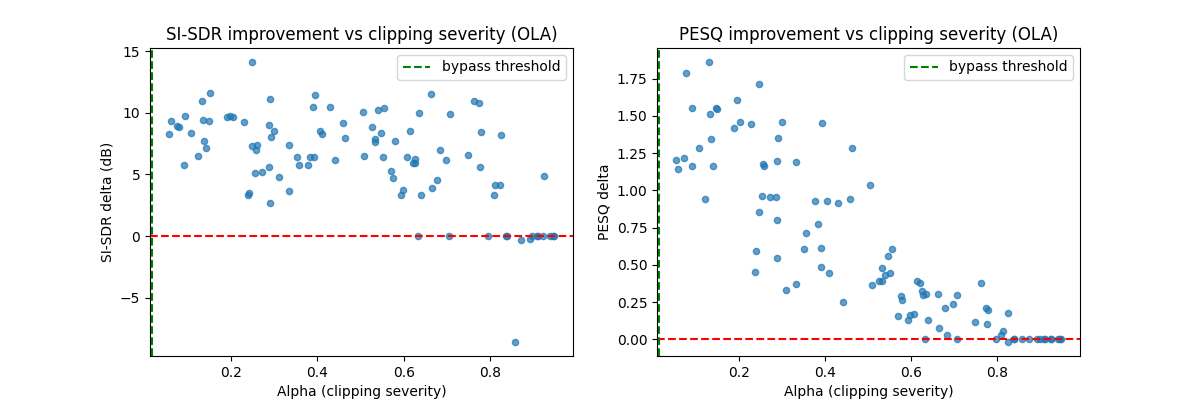

In [8]:
# Stratified results by clipping severity (alpha from manifest) — OLA + routed

bins = [(0.05, 0.35), (0.35, 0.65), (0.65, 0.95)]
bin_labels = ["light (α=0.05-0.35)", "moderate (α=0.35-0.65)", "severe (α=0.65-0.95)"]

for (lo, hi), label in zip(bins, bin_labels):
    indices = [i for i, e in enumerate(test_manifest) if lo <= e["alpha"] < hi]
    if not indices:
        continue

    sdr_improvements = [test_sdr_ola[i] - test_baseline_scores_ola[i] for i in indices]
    pesq_improvements = [test_pesq_ola[i] - test_baseline_pesq_ola[i] for i in indices]
    baseline_sdrs = [test_baseline_scores_ola[i] for i in indices]
    baseline_pesqs = [test_baseline_pesq_ola[i] for i in indices]

    print(f"\n{label} ({len(indices)} utterances)")
    print(f"  Mean baseline SI-SDR:  {np.mean(baseline_sdrs):.4f} dB")
    print(f"  Mean SI-SDR delta:     {np.mean(sdr_improvements):.4f} dB")
    print(f"  Mean baseline PESQ:    {np.mean(baseline_pesqs):.4f}")
    print(f"  Mean PESQ delta:       {np.nanmean(pesq_improvements):.4f}")

# Scatter plot: alpha vs SI-SDR delta and PESQ delta
alphas = [e["alpha"] for e in test_manifest]
sdr_deltas = [test_sdr_ola[i] - test_baseline_scores_ola[i] for i in range(len(test_manifest))]
pesq_deltas = [test_pesq_ola[i] - test_baseline_pesq_ola[i] for i in range(len(test_manifest))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(alphas, sdr_deltas, s=20, alpha=0.7)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].axvline(x=FC_BYPASS_OLA, color='g', linestyle='--', label='bypass threshold')
axes[0].set_xlabel("Alpha (clipping severity)")
axes[0].set_ylabel("SI-SDR delta (dB)")
axes[0].set_title("SI-SDR improvement vs clipping severity (OLA)")
axes[0].legend()

axes[1].scatter(alphas, pesq_deltas, s=20, alpha=0.7)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].axvline(x=FC_BYPASS_OLA, color='g', linestyle='--', label='bypass threshold')
axes[1].set_xlabel("Alpha (clipping severity)")
axes[1].set_ylabel("PESQ delta")
axes[1].set_title("PESQ improvement vs clipping severity (OLA)")
axes[1].legend()

plt.show()